In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [151]:
def rename_columns(df, old_cols, new_cols):
    """
    Rename a series of columns using two aligned lists.
    """
    if len(old_cols) != len(new_cols):
        raise ValueError("old_cols and new_cols must have the same length")

    return df.rename(columns=dict(zip(old_cols, new_cols)))

## Transformer

In [ ]:
# if args.type == 'txfr':

        ### transmission asset

file_loc = r"TXFR-T_REPLACEMENT LIST_01_12_26.xlsm"
df = pd.read_excel(file_loc, sheet_name = "Mar 2026 Repl Ranking by Phase", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF ',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_txfr = df[sel_cols]

df_t_txfr=rename_columns(df_t_txfr, ['SAP Equipment ID', 'Sub Name', 'Highest Cumulative POF '], 
                                ['Equipment', 'Substation Name', 'POF'])

df_t_txfr['line'] = 'T'

    ### distribution asset

file_loc = r"D_Transf_Risk_Ranking_Under_Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Transformers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['SAP Equipment I.D.', 'Substation Name', 'Highest POF ','Reliability Risk Matrix (PoF,CoF)']

df_d_txfr = df[sel_cols]

df_d_txfr=rename_columns(df_d_txfr, ['SAP Equipment I.D.', 'Highest POF '], 
                        ['Equipment', 'POF'])

df_d_txfr['line'] = 'D'
# if args.line ==1:
asset_files = pd.concat([df_d_txfr, df_t_txfr])

asset_files = asset_files[~((asset_files['Equipment'].isin([41158251,
41158253,
41158254,
44918680,
45247388,
45274594])) & (asset_files['line']=='T'))]


In [160]:
print(f"total transformers: {len(asset_files)}\n\
total distribution transofrmers: {len(asset_files[asset_files['line']=='D'])}\n\
total transmission transformers: {len(asset_files[asset_files['line']=='T'])}"
)

total transformers: 2373
total distribution transofrmers: 1923
total transmission transformers: 450


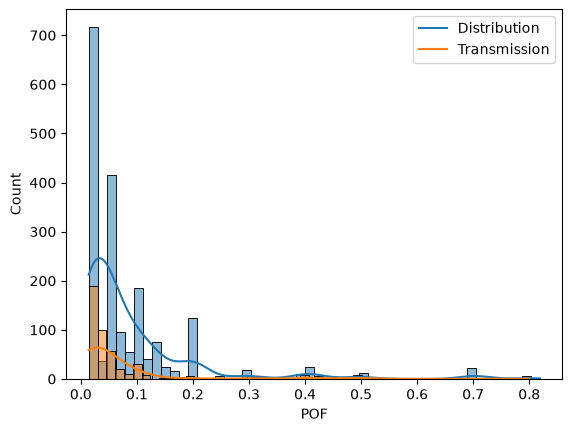

In [161]:
sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [164]:
print(f"summary stat total: {asset_files.POF.describe()}\n\
sum of POF: {asset_files.POF.sum()}")

summary stat total: count    2373.000000
mean        0.085852
std         0.118801
min         0.014000
25%         0.020000
50%         0.050000
75%         0.100000
max         0.818520
Name: POF, dtype: float64
sum of POF: 203.72685497042255


In [165]:
print(f"summary stat transformer distribution: {asset_files[asset_files['line']=='D'].POF.describe()}\n\
sum of POF: {asset_files[asset_files['line']=='D'].POF.sum()}")

summary stat transformer distribution: count    1923.000000
mean        0.090321
std         0.120471
min         0.014000
25%         0.020000
50%         0.050000
75%         0.100000
max         0.818520
Name: POF, dtype: float64
sum of POF: 173.6874516247123


In [166]:
print(f"summary stat transformer transmission: {asset_files[asset_files['line']=='T'].POF.describe()}\n\
sum of POF: {asset_files[asset_files['line']=='T'].POF.sum()}")

summary stat transformer transmission: count    450.000000
mean       0.066754
std        0.109469
min        0.014000
25%        0.014832
50%        0.030000
75%        0.060000
max        0.800000
Name: POF, dtype: float64
sum of POF: 30.03940334571026


In [ ]:
df_f_txfr = pd.read_csv(r"C:\Users\SIH5\OneDrive - PGE\Desktop\transformer failures\txfr_brkr_failures\transformers_foundary.csv")

In [ ]:
df_f_txfr = df_f_txfr[df_f_txfr['system_status'].isin(['[INST]', '[INAC, INST]'])]
df_f_txfr = df_f_txfr[df_f_txfr['planner_group'].isin(['TS1', 'DS1'])]

In [ ]:
pd.merge(asset_files, df_f_txfr, left_on='Equipment', right_on='sap_equipment_id', how='left')[pd.merge(asset_files, df_f_txfr, left_on='Equipment', right_on='sap_equipment_id', how='left')[
    'sap_equipment_id'].isna()]#['system_status'].unique() #, 'planner_group'

,Equipment,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line,substation_transformer_id,sap_equipment_id,user_status,substation_id,substation_name,...,nlt_a_1_pri_rated_voltage_v,nlt_b_2_pri_rated_voltage_v,nlt_c_3_pri_rated_voltage_v,nlt_d_4_pri_rated_voltage_v,nlt_e_5_pri_rated_voltage_v,nlt_a_1_sec_rated_voltage_v,nlt_b_2_sec_rated_voltage_v,nlt_c_3_sec_rated_voltage_v,nlt_d_4_sec_rated_voltage_v,nlt_e_5_sec_rated_voltage_v
510,41012511,ARBUCKLE,0.400068,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
599,41014124,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
600,41014066,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
601,41014093,ARBUCKLE,0.070000,22,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1923,42735572,ARCO SUB,0.014276,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1924,43144204,ARCO SUB,0.020000,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1925,42553779,BRIDGEVILLE SUB,0.070982,24,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926,42734697,BUTTE SUB,0.050000,24,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1927,41184033,CHRISTIE SUB,0.014208,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928,40989612,COBURN SUB,0.025000,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cicuit Breaker

In [167]:
### transmission asset
file_loc = r"T_BRKR 1-N Under Const (1 15 2026).xlsx"
df = pd.read_excel(file_loc, sheet_name = "Transmission Breakers", index_col=None, na_values=['NA'], skiprows=0)

sel_cols = [' Equipment', 'Substation Name', 'Highest PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_t_brkr = df[sel_cols]


df_t_brkr=rename_columns(df_t_brkr, [' Equipment', 'Highest PoF'], 
                        ['Equipment', 'POF'])

df_t_brkr['line'] = 'T'
### distribution asset
file_loc = r"D BRKR 1-N Under Const 2026.xlsx"
df = pd.read_excel(file_loc, sheet_name = "Distribution Breakers", index_col=None, na_values=['NA'], skiprows=0, engine='openpyxl')

sel_cols = ['Equipment', 'Substation Name', 'Highest Cummulative PoF',
            'Reliability Risk Matrix (PoF,CoF)']

df_d_brkr = df[sel_cols]

df_d_brkr=rename_columns(df_d_brkr, ['Highest Cummulative PoF'], 
                        ['POF'])


df_d_brkr['line'] = 'D'


asset_files = pd.concat([df_d_brkr, df_t_brkr])
asset_files = asset_files[~((asset_files['Equipment'].isin([40991421])) & (asset_files['line']=='T'))]

In [168]:
print(f"total CB: {len(asset_files)}\n\
total distribution CB: {len(asset_files[asset_files['line']=='D'])}\n\
total transmission CB: {len(asset_files[asset_files['line']=='T'])}"
)

total CB: 6747
total distribution CB: 3014
total transmission CB: 3733


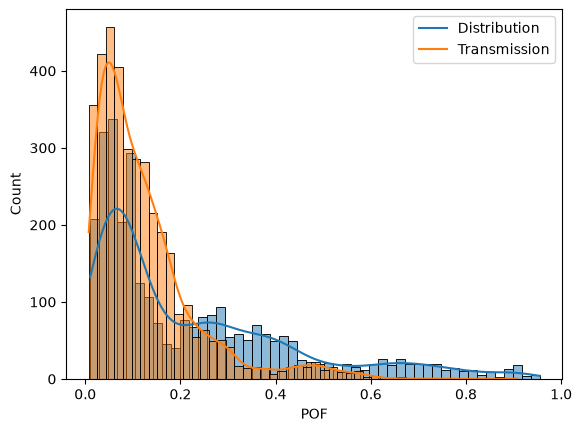

In [169]:
sns.histplot(data=asset_files[asset_files['line']=='D'], x='POF', bins=50, kde=True)
sns.histplot(data=asset_files[asset_files['line']=='T'], x='POF', bins=50, kde=True)
plt.legend(['Distribution', 'Transmission'])
plt.show()

In [170]:
print(f"summary stat total: {asset_files.POF.describe()}\n\
sum of POF: {asset_files.POF.sum()}")

summary stat total: count    6747.000000
mean        0.167418
std         0.171189
min         0.007292
25%         0.054117
50%         0.103353
75%         0.218603
max         0.954712
Name: POF, dtype: float64
sum of POF: 1129.5692796165367


In [171]:
print(f"summary stat CB distribution: {asset_files[asset_files['line']=='D'].POF.describe()}\n\
sum of POF: {asset_files[asset_files['line']=='D'].POF.sum()}")

summary stat CB distribution: count    3014.000000
mean        0.222518
std         0.213414
min         0.010400
25%         0.060326
50%         0.126406
75%         0.328613
max         0.954712
Name: POF, dtype: float64
sum of POF: 670.6681157684814


In [172]:
print(f"summary stat CB transmission: {asset_files[asset_files['line']=='T'].POF.describe()}\n\
sum of POF: {asset_files[asset_files['line']=='T'].POF.sum()}")

summary stat CB transmission: count    3733.000000
mean        0.122931
std         0.108493
min         0.007292
25%         0.049402
50%         0.092154
75%         0.159033
max         0.907200
Name: POF, dtype: float64
sum of POF: 458.9011638480553


In [ ]:
df_f_brkr = pd.read_csv(r"C:\Users\SIH5\OneDrive - PGE\Desktop\transformer failures\txfr_brkr_failures\circuitbreaker_foundary.csv")

In [ ]:
[pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='inner')['system_status']=='']#['system_status'].unique()

In [147]:
pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='left')[
    pd.merge(asset_files, df_f_brkr, left_on='Equipment', right_on='sap_equipment_id', how='left')['sap_equipment_id'].isna()
]

,Equipment,Substation Name,POF,"Reliability Risk Matrix (PoF,CoF)",line,ed_circuitbreaker_id,asset_kind,gis_globalid,sap_equipment_id,position,...,reclose_blocking_idc_code,reclosing_capability_idc,reclosing_capability_idc_code,scada_idc,scada_idc_code,status,status_code,control_ser_num,epss_device,region
330,40995300,STELLING SUB,0.602107,43,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
480,40995565,BULLARD SUB,0.385208,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
551,40992191,CAMP EVERS SUB,0.756000,53,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
846,40992500,GIFFEN SUB,0.315695,42,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1940,40990870,KERN OIL SUB,0.253795,43,D,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6324,44706773,"ORO LOMA SUB, CIRCUIT BREAKERS",0.027724,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6471,45040548,"FMC SUB, CIRCUIT BREAKERS",0.022937,14,T,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
df_f_brkr[(df_f_brkr['planner_group'].isin(['DS1', 'TS1'])) & (df_f_brkr['system_status'].isin(['[INST]', '[INAC, INST]']))][
    df_f_brkr[(df_f_brkr['planner_group'].isin(['DS1', 'TS1'])) & (df_f_brkr['system_status'].isin(['[INST]', '[INAC, INST]']))]['planner_group']=='DS1'
]

,ed_circuitbreaker_id,asset_kind,gis_globalid,sap_equipment_id,position,equipment_description,substation_feeder_id,substation_functional_location,city,city_curation_notes,...,reclose_blocking_idc_code,reclosing_capability_idc,reclosing_capability_idc_code,scada_idc,scada_idc_code,status,status_code,control_ser_num,epss_device,region
0,40997243-{82F52100-EF6A-4495-9E78-3704DCB379DD},substationCircuitbreaker,{82F52100-EF6A-4495-9E78-3704DCB379DD},40997243.0,1101,1101 DIST. OIL BREAKER 3 TANK,1311BK1,ETS.09.12959,SAN LEANDRO,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NaN,NaN,North Valley & Sierra
4,40993723-{3B19E3F6-C66B-4694-9381-0B80F3B7C764},substationCircuitbreaker,{3B19E3F6-C66B-4694-9381-0B80F3B7C764},40993723.0,1110,1110 DISTRIBUTION VACUUM BREAKER,10297BK3,ETS.19.13082,CHICO,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,MAHC14000054,No,North Valley & Sierra
10,40992148-NA,substationCircuitbreaker,NaN,40992148.0,NaN,1101 DISTRIBUTION VACUUM BREAKER,NaN,ETS.02.12184,ROUND MOUNTAIN,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,42568443-NA,substationCircuitbreaker,NaN,42568443.0,NaN,BK 1 DISTRIBUTION VACUUM BREAKER,NaN,ETS.12.12948,SAN FRANCISCO,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,45511269-NA,substationCircuitbreaker,NaN,45511269.0,1200,1200 DISTRIBUTION VACUUM BREAKER,NaN,ETS.06.10097,EUREKA,GIS missing city,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18945,45587983-{E247EBBF-8B5D-49E6-B3DE-54825EF4E09C},substationCircuitbreaker,{E247EBBF-8B5D-49E6-B3DE-54825EF4E09C},45587983.0,1102.0,1102 DISTRIBUTION VACUUM BREAKER,15206BK1,ETS.04.13606,ROCKLIN,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,AAHC13002474,NaN,North Valley & Sierra
18946,40992184-{E4917E6F-1BA6-4862-A8C9-4C8A7009E9E7},substationCircuitbreaker,{E4917E6F-1BA6-4862-A8C9-4C8A7009E9E7},40992184.0,1101.0,1101 DISTRIBUTION VACUUM BREAKER,4282BK1,ETS.13.12218,CLOVERDALE,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,AAHC16001371,Yes,North Coast
18948,40993063-{3CA2D923-0637-4424-B939-A09B0DEC4FEC},substationCircuitbreaker,{3CA2D923-0637-4424-B939-A09B0DEC4FEC},40993063.0,1109.0,1109 DISTRIBUTION VACUUM BREAKER,1376BK1,ETS.09.12736,HAYWARD,mismatched citys; SAP chosen,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NaN,NaN,North Valley & Sierra
18951,40990180-{F878E505-B299-489C-AAE0-26906AE947F2},substationCircuitbreaker,{F878E505-B299-489C-AAE0-26906AE947F2},40990180.0,1102.0,1102 DISTRIBUTION VACUUM BREAKER,25361BK2,ETS.14.12045,ATWATER,GIS missing city,...,NaN,NaN,NaN,Yes,Y,In Service,5.0,NONE,NaN,NaN
